In [1]:
import polars as pl
from hydra import initialize, compose
from pathlib import Path
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
with initialize(version_base=None, config_path="../configs/filepaths"):
    cfg = compose(config_name="filepaths")

In [3]:
d = pl.read_parquet(Path(cfg.raw_data) / "distilled_mech_reactions.parquet")
d.head()

entry_id,mechanism_id,smarts,am_smarts,reaction_center,mech_atoms,enzyme_name,uniprot_id,ec,reported_direction
i64,i64,str,str,str,str,str,str,str,bool
1,1,"""NC(CCC(=O)O)C(=O)O>>NC(CCC(=O)…","""[NH2:26][CH:25]([CH2:27][CH2:3…","""7,8,9>>7,8,9""","""1>>1""","""glutamate racemase""","""P56868""","""5.1.1.3""",true
1,1,"""NC(CCC(=O)O)C(=O)O>>NC(CCC(=O)…","""[NH2:26][CH:25]([CH2:27][CH2:3…","""7,8,9>>7,8,9""","""1>>1""","""glutamate racemase""","""P56868""","""5.1.1.3""",false
2,2,"""*C(=O)NC1C(=O)N2C1SC(C)(C)C2C(…","""[*:33][C:32](=[O:35])[NH:30][C…","""5,7;0>>5,7,9""","""6;>>6""","""beta-lactamase (Class A)""","""P62593""","""3.5.2.6""",true
2,2,"""*C(=O)NC(C(=O)O)C1NC(C(=O)O)C(…","""[*:33][C:32](=[O:35])[NH:30][C…","""5,7,9>>5,7;0""","""6>>6;""","""beta-lactamase (Class A)""","""P62593""","""3.5.2.6""",false
2,1,"""*C(=O)NC1C(=O)N2C1SC(C)(C)C2C(…","""[*:51][C:50](=[O:52])[NH:48][C…","""5,7;0>>5,7,9""","""6;>>6""","""beta-lactamase (Class A)""","""P62593""","""3.5.2.6""",true


In [4]:
krs = pl.read_parquet(Path(cfg.raw_data) / "mapped_known_reactions_x_rc_plus_0_rules.parquet")
krs.head()

rxn_id,smarts,am_smarts,rule,template_aidxs,rule_id
str,str,str,str,str,i64
"""4fc554b86bb64504ce3bb78f4c02ac…","""*C#N.O>>*C(N)=O""","""[*:4][C:2]#[N:1].[OH2:3]>>[*:4…","""[#6:1]#[#7:2].[#8:3]>>[#7:2]-[…","""1,2;0>>1,2,3""",549
"""4fe435c487c7b2dc720dff02a9af2d…","""*C#N.O>>*C=NO""","""[*:4][C:1]#[N:2].[OH2:3]>>[*:4…","""[#6:1]#[#7:2].[#8:3]>>[#6:1]=[…","""1,2;0>>1,2,3""",785
"""db3a4d53e3f2557babac4615ca5518…","""*C(*)S.*C(*)S.O=O>>*C(*)SSC(*)…","""[*:4][CH:3]([*:5])[SH:1].[*:7]…","""[#16:1].[#16:2].[#8:3]=[#8:4]>…","""3;3;0,1>>3,4;0,1""",747
"""74aa76da460568ccddd08f17f78cd8…","""*C(*)SSC(*)*.OO>>*C(*)S.*C(*)S…","""[*:3][CH:2]([*:4])[S:1][S:5][C…","""[#16:1]-[#16:2].[#8:3]-[#8:4]>…","""3,4;0,1>>3;3;0,1""",225
"""40c96410b09d3b0ef8fb9420f28029…","""*C(=Cc1c(*)c(*)c(*)c(*)c1*)C(=…","""[*:16][C:1](=[CH:2][c:17]1[c:1…","""([#8:1].[#6:2]=[#6:3])>>[#6:2]…","""26,1,2>>7,8,21""",412


In [5]:
pub = pl.read_parquet(Path(cfg.raw_data) / "rxn_pub_dates.parquet")
pub.head()

id,smarts,enzymes,reverse,db_ids,pubmed_ids,publication_dates
str,str,list[str],str,list[str],list[i32],list[i32]
"""e908a824c912d1e39c46de92d1f738…","""**.NC(CCC(=O)NC(CS)C(=O)NCC(=O…","[""P15964"", ""A2XMN2"", … ""P31670""]","""3bbe8e6dca0da1c745e7678c8efebe…","[""RHEA:16438""]","[28223489, 18567690, … 32181246]","[1986, 1988, … 2020]"
"""d86d99a8143d3be8fc861a5de5e625…","""*.*.*.*.*.*.*.*.*.*.CC(C)(COP(…","[""Q0UK48"", ""A0A0C6E0I7"", … ""Q0UK50""]","""e99fb0b75e799eba72aee21c1d04ee…","[""RHEA:51350""]","[31553484, 25530455]","[2019, 2015]"
"""2972b2db66715ba6f3d6aeaf07f31b…","""*.*.*.*.*.*.*.*.*NC(COP(=O)(O)…","[""P0DO30"", ""G0REX6"", ""A0A482N9V7""]","""5a7fffef224c65b7cd431ddc668eb2…","[""RHEA:64546""]","[34947016, 30905148, 31216742]","[2019, 2021]"
"""572e4a84a946af07c9ab6fd1c0347b…","""*.*.*.*.*.*.*.*.*OP(=O)(O)OCC(…","[""Q979Y7"", ""Q12WF0"", … ""Q6L0M1""]","""c4c936d8d985a457a128601b8d2769…","[""RHEA:64377""]","[18375567, 17288560, … 24954619]","[2006, 2007, … 2014]"
"""dfe7fc761de3c213bf2b18fae4f8a5…","""*.*.*.*.*.*.*.*.CC(C)CCCC(C)CC…","[""O27753"", ""Q9V2B0"", … ""Q2NER9""]","""2e026380a550baa6b343604e6f5500…","[""RHEA:64369""]","[17288560, 18375567]","[2008, 2007]"


In [7]:
krs = krs.join(
    pub.select(["id", "publication_dates"]),
    left_on='rxn_id',
    right_on='id',
    how='left'
).with_columns(
    pl.col("publication_dates").list.first().alias("first_publication_date")
)
krs.head()

rxn_id,smarts,am_smarts,rule,template_aidxs,rule_id,publication_dates,first_publication_date
str,str,str,str,str,i64,list[i32],i32
"""4fc554b86bb64504ce3bb78f4c02ac…","""*C#N.O>>*C(N)=O""","""[*:4][C:2]#[N:1].[OH2:3]>>[*:4…","""[#6:1]#[#7:2].[#8:3]>>[#7:2]-[…","""1,2;0>>1,2,3""",549,"[2017, 1989, … 2014]",2017
"""4fe435c487c7b2dc720dff02a9af2d…","""*C#N.O>>*C=NO""","""[*:4][C:1]#[N:2].[OH2:3]>>[*:4…","""[#6:1]#[#7:2].[#8:3]>>[#6:1]=[…","""1,2;0>>1,2,3""",785,"[2003, 2004, … 2013]",2003
"""db3a4d53e3f2557babac4615ca5518…","""*C(*)S.*C(*)S.O=O>>*C(*)SSC(*)…","""[*:4][CH:3]([*:5])[SH:1].[*:7]…","""[#16:1].[#16:2].[#8:3]=[#8:4]>…","""3;3;0,1>>3,4;0,1""",747,"[2016, 2018, … 2013]",2016
"""74aa76da460568ccddd08f17f78cd8…","""*C(*)SSC(*)*.OO>>*C(*)S.*C(*)S…","""[*:3][CH:2]([*:4])[S:1][S:5][C…","""[#16:1]-[#16:2].[#8:3]-[#8:4]>…","""3,4;0,1>>3;3;0,1""",225,"[2016, 2018, … 2013]",2016
"""40c96410b09d3b0ef8fb9420f28029…","""*C(=Cc1c(*)c(*)c(*)c(*)c1*)C(=…","""[*:16][C:1](=[CH:2][c:17]1[c:1…","""([#8:1].[#6:2]=[#6:3])>>[#6:2]…","""26,1,2>>7,8,21""",412,[],null


In [13]:
n_rxns_w_date = krs.filter(~pl.col("first_publication_date").is_null()).shape[0]
print(f"{n_rxns_w_date} / {krs.height} ({(n_rxns_w_date / krs.height * 100):.1f}%) reactions have a publication date.")

14025 / 19433 (72.2%) reactions have a publication date.


In [58]:

krs_w_date = krs.filter(~pl.col("first_publication_date").is_null())

# Collapse reaction direction

rxn_id_pairs = dict(zip(pub['id'], pub['reverse']))
id2dates = dict(zip(pub['id'], pub['publication_dates']))
rev_dates = {k: id2dates[v] for k, v in rxn_id_pairs.items() if v in id2dates}
def augment_dates_w_rev(rxn_id: int, rev_dates = rev_dates, id2dates = id2dates) -> list[int]:
    dates = id2dates.get(rxn_id, [])
    rev_dates = rev_dates.get(rxn_id, [])
    date_ctr = Counter(dates)
    rev_ctr = Counter(rev_dates)
    combo = {k: max(date_ctr.get(k, 0), rev_ctr.get(k, 0)) for k in set(date_ctr) | set(rev_ctr)}
    combined_dates = []
    for date, count in combo.items():
        combined_dates.extend([date] * count)
    return combined_dates

krs_w_date = krs_w_date.with_columns(
    pl.col("rxn_id").map_elements(augment_dates_w_rev, return_dtype=pl.List(pl.Int32)).alias("publication_dates")
)

unique_rids = set(krs_w_date['rxn_id'])
def canonicalize_direction(rxn_id: int, rxn_id_pairs = rxn_id_pairs, unique_rids = unique_rids) -> bool:
    if rxn_id not in rxn_id_pairs:
        return True
    
    rev_id = rxn_id_pairs[rxn_id]
    lesser = rxn_id < rev_id
    if lesser:
        return True
    elif not lesser and rev_id not in unique_rids:
        return True
    else:
        return False

krs_w_date = krs_w_date.filter(pl.col("rxn_id").map_elements(canonicalize_direction, return_dtype=pl.Boolean))
krs_w_date.head()

rxn_id,smarts,am_smarts,rule,template_aidxs,rule_id,publication_dates,first_publication_date
str,str,str,str,str,i64,list[i32],i32
"""4fc554b86bb64504ce3bb78f4c02ac…","""*C#N.O>>*C(N)=O""","""[*:4][C:2]#[N:1].[OH2:3]>>[*:4…","""[#6:1]#[#7:2].[#8:3]>>[#7:2]-[…","""1,2;0>>1,2,3""",549,"[1989, 1991, … 2025]",2017
"""74aa76da460568ccddd08f17f78cd8…","""*C(*)SSC(*)*.OO>>*C(*)S.*C(*)S…","""[*:3][CH:2]([*:4])[S:1][S:5][C…","""[#16:1]-[#16:2].[#8:3]-[#8:4]>…","""3,4;0,1>>3;3;0,1""",225,"[2000, 2001, … 2019]",2016
"""d31a1334f694b47d6a71cf52dd664a…","""NC(=O)C1=CN(C2OC(COP(=O)(O)OP(…","""[NH2:16][C:15](=[O:17])[C:9]1=…","""[#6:1]1=[#6:2]-[#7:3]-[#6:4]=[…","""3,4,5,45,46,47;1,2>>1,2;3,4,5,…",559,[2011],2011
"""374565644f8e35592c0f7a84b150db…","""*C(NC(=O)CCC(N)C(=O)O)C(=O)O.*…","""[*:18][CH:17]([NH:16][C:1](=[O…","""[#6:1]-[#7:2].[#7:3]>>[#6:1]-[…","""3,2;5>>5,6;2""",316,"[1984, 1991, … 1982]",1984
"""1df0c98f185e6581109d26af4be03e…","""CC(=O)SCCNC(=O)CCNC(=O)C(O)C(C…","""[CH3:51][C:49](=[O:52])[S:1][C…","""[#6:1]-[#16:2].[#7:3]>>[#16:2]…","""1,3;5>>47;5,6""",347,"[2020, 2015]",2020


In [59]:
def get_unique_cpds(smarts):
    unique_cpds = set()
    for part in smarts.split(">>"):
        for cpd in part.split("."):
            unique_cpds.add(cpd)
    return list(unique_cpds)

cpd_dates = krs_w_date.with_columns(
    pl.col("smarts").map_elements(get_unique_cpds, return_dtype=pl.List(pl.String)).alias("unique_cpds")
).select(["unique_cpds", "first_publication_date"]).explode("unique_cpds").rename({"unique_cpds": "cpd", "first_publication_date": "date"}).unique(subset=["cpd", "date"])
cpd_dates.head()

cpd,date
str,i32
"""CC(C)=CCCC(C)=CCc1cc(C(=O)O)cc…",2002
"""CC12CCC3c4ccc(O)cc4CCC3C1CCC2=…",2018
"""CCCCCCCC(=O)OCC(COP(=O)(O)OCC[…",2002
"""CCCCCCCCCCCCCC(=O)OC(CCCCCCCCC…",2008
"""O=CC(O)C(O)C(O)C(O)C(=O)O""",2022


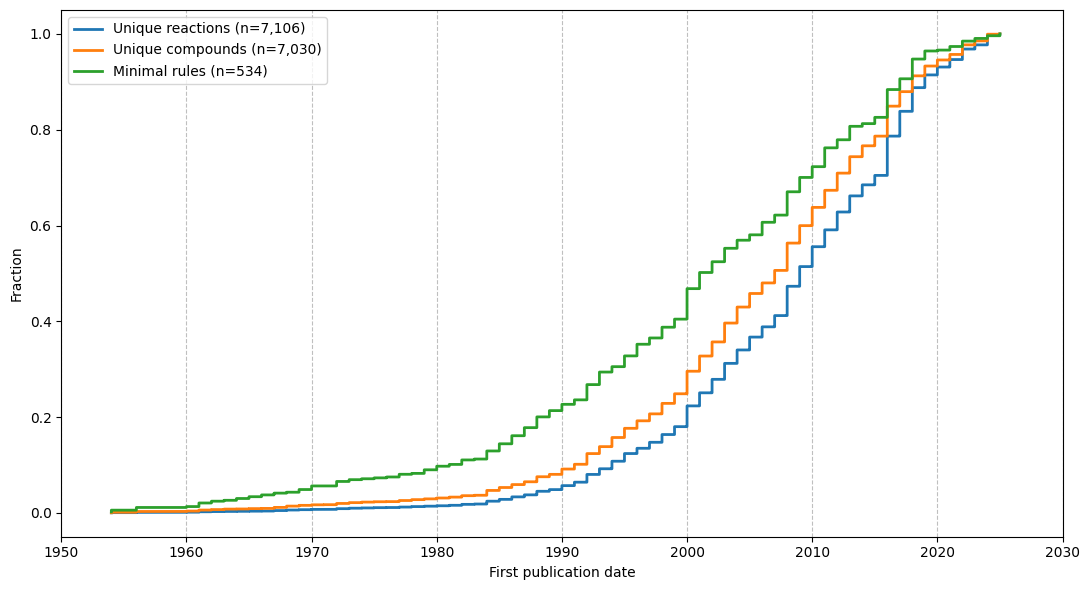

In [60]:
# Build first-publication year per entity
rxn_first = (
    krs_w_date
    .group_by("rxn_id")
    .agg(pl.col("first_publication_date").min().alias("year"))
    .drop_nulls("year")
    .sort("year")
)

rule_first = (
    krs_w_date
    .group_by("rule_id")
    .agg(pl.col("first_publication_date").min().alias("year"))
    .drop_nulls("year")
    .sort("year")
)

cpd_first = (
    cpd_dates
    .group_by("cpd")
    .agg(pl.col("date").min().alias("year"))
    .drop_nulls("year")
    .sort("year")
)

def ecdf_xy(df, col="year"):
    x = df[col].to_list()
    n = len(x)
    y = [(i + 1) / n for i in range(n)]
    return x, y

x_rxn, y_rxn = ecdf_xy(rxn_first)
x_cpd, y_cpd = ecdf_xy(cpd_first)
x_rule, y_rule = ecdf_xy(rule_first)

all_years = x_rxn + x_cpd + x_rule
x_start = (min(all_years) // 10) * 10
x_end = ((max(all_years) + 9) // 10) * 10

plt.figure(figsize=(11, 6))
plt.step(x_rxn, y_rxn, where="post", label=f"Unique reactions (n={len(x_rxn):,})", linewidth=2)
plt.step(x_cpd, y_cpd, where="post", label=f"Unique compounds (n={len(x_cpd):,})", linewidth=2)
plt.step(x_rule, y_rule, where="post", label=f"Minimal rules (n={len(x_rule):,})", linewidth=2)

plt.xlabel("First publication date")
plt.ylabel("Fraction")
plt.xticks(range(x_start, x_end + 1, 10))
plt.grid(axis="x", linestyle="--", alpha=0.8)
plt.legend()
plt.tight_layout()
plt.show()

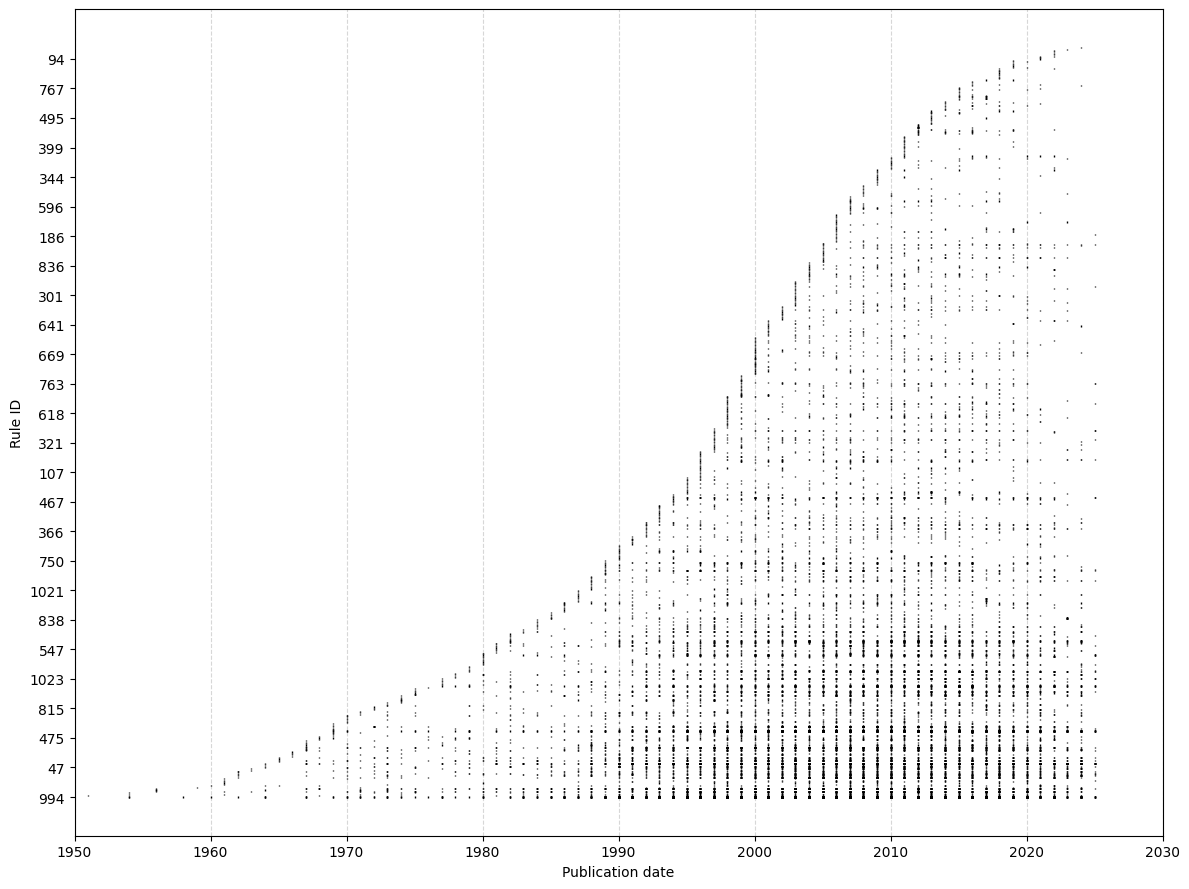

In [64]:
rule_pub = (
    krs_w_date.select(["rule_id", "publication_dates"])
    .explode("publication_dates")
    .rename({"publication_dates": "year"})
    .drop_nulls("year")
)

rule_events = (
    rule_pub
    .group_by("rule_id")
    .agg(
        pl.col("year").sort().alias("years"),
        pl.col("year").min().alias("earliest_year"),
    )
    .sort(["earliest_year", "rule_id"])
)

event_data = rule_events["years"].to_list()
rule_ids_sorted = rule_events["rule_id"].to_list()
line_offsets = list(range(len(rule_ids_sorted)))

plt.figure(figsize=(12, 9))
plt.eventplot(
    event_data,
    orientation="horizontal",
    lineoffsets=line_offsets,
    linelengths=0.8,
    linewidths=1.0,
    colors="black",
)

step = max(1, len(rule_ids_sorted) // 25)
tick_pos = list(range(0, len(rule_ids_sorted), step))
plt.yticks(tick_pos, [rule_ids_sorted[i] for i in tick_pos])

plt.xlabel("Publication date")
plt.ylabel("Rule ID")
plt.xlim(x_start, x_end)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

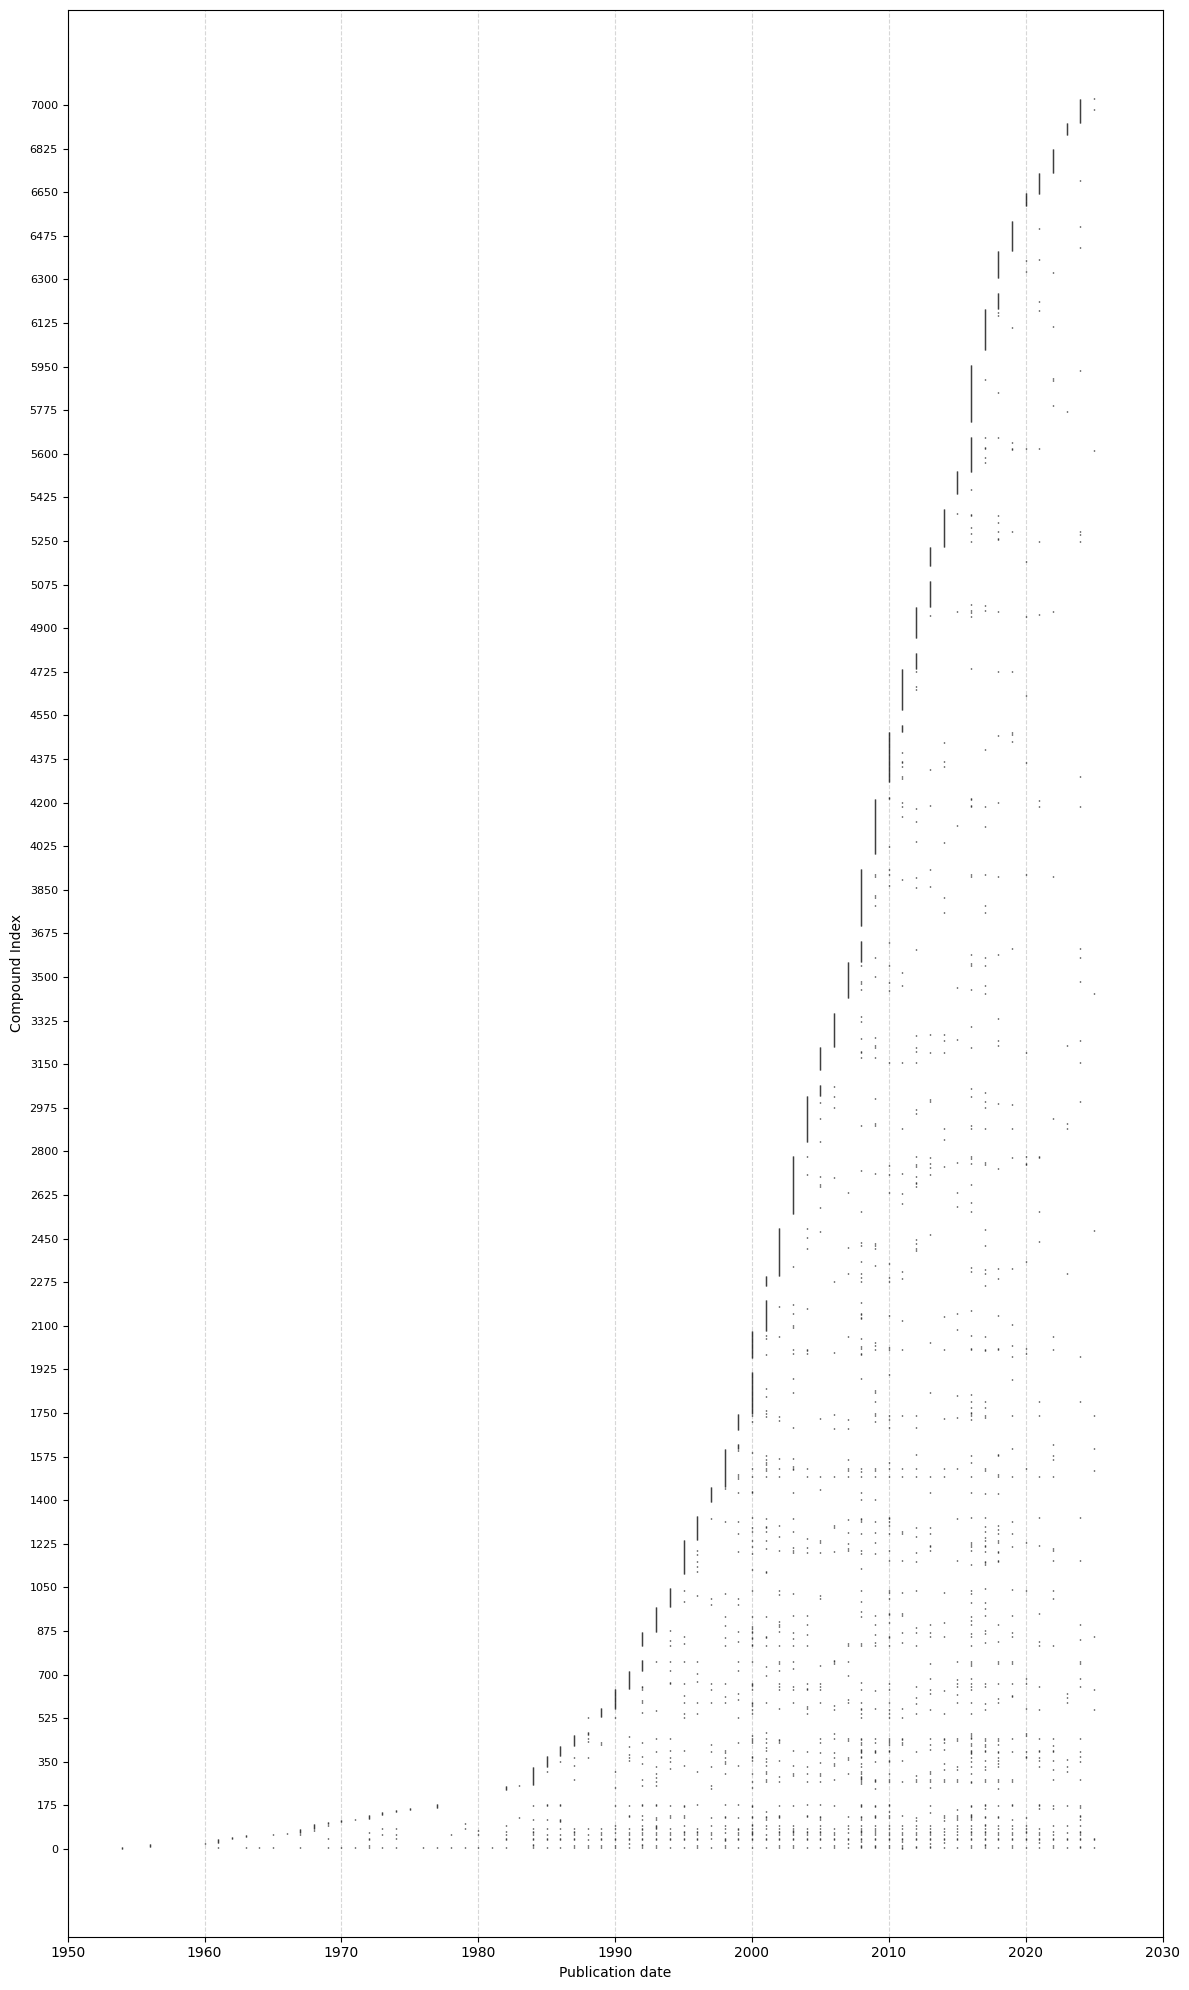

In [63]:
cpd_events = (
    cpd_dates
    .group_by("cpd")
    .agg(
        pl.col("date").sort().alias("years"),
        pl.col("date").min().alias("earliest_date"),
    )
    .sort(["earliest_date", "cpd"])
)

event_data_cpd = cpd_events["years"].to_list()
cpds_sorted = cpd_events["cpd"].to_list()
line_offsets_cpd = list(range(len(cpds_sorted)))

plt.figure(figsize=(12, 20))
plt.eventplot(
    event_data_cpd,
    orientation="horizontal",
    lineoffsets=line_offsets_cpd,
    linelengths=0.8,
    linewidths=1.0,
    colors="black",
)

step_cpd = max(1, len(cpds_sorted) // 40)
tick_pos_cpd = list(range(0, len(cpds_sorted), step_cpd))
plt.yticks(tick_pos_cpd, tick_pos_cpd, fontsize=8)

plt.xlabel("Publication date")
plt.ylabel("Compound Index")
plt.xlim(x_start, x_end)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
